In [33]:
using Pkg; Pkg.activate(".")
using PythonPlot
using M1DIS
using DelimitedFiles;

  Activating project at `~/M1DIS`


In [34]:
MUST = M1DIS.MUST
plt = matplotlib.pyplot;

# Loading the atmosphere
The atmosphere is stored in the same format as in M3DIS, which allows to use the same functions.

In [35]:
model_dir = "M1DIS.jl/models/"
model_name = "m1dis_model";

In [36]:
atmos = MUST.Box(joinpath(model_dir, model_name, model_name*".hdf5"));

You can also load individual iterations if you like

In [37]:
iters = MUST.glob("iter*/", joinpath(model_dir, model_name, "iterations"))
iters_number = parse.(Int, split.(split.(iters, '/', keepempty=false) .|> last, '_') .|> last)
m = sortperm(iters_number)
iters = iters[m]
iters_number = iters_number[m]
iter_ms = [m = MUST.Box(joinpath(iterdir, "iteration_$(iternumber).hdf5")) for (iterdir, iternumber) in zip(iters, iters_number)];

# Plotting the structure
Plotting is straight forward, you can use the same funtions as in `MUST.jl`, or simply get the data by accessing the `atmos.data` dict.

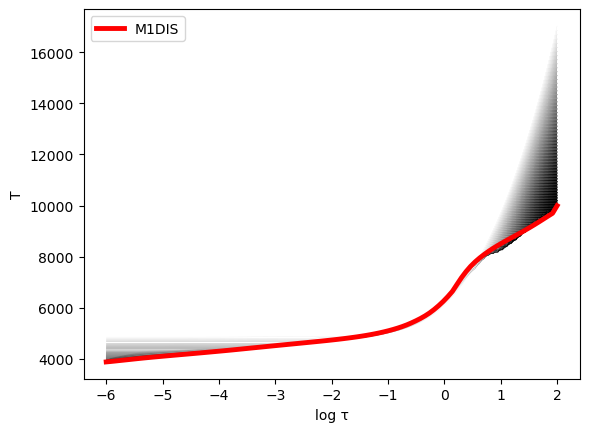

In [38]:
f, ax = plt.subplots(1, 1)

for iternumber in eachindex(iters)
    m = iter_ms[iternumber]
    ax.plot(MUST.profile(MUST.mean, m, :log10τ_ross, :T)..., lw = iternumber/maximum(iters_number)*1, color="k")
end

ax.plot(MUST.profile(MUST.mean, atmos, :log10τ_ross, :T)..., lw=3.5, label="M1DIS", color="r")

ax.set_ylabel("T")
ax.set_xlabel("log τ")
ax.legend();

In [39]:
@info "available fields to plot:"
for k in keys(atmos.data)
    @info k
end

[ Info: available fields to plot:
[ Info: F_err_rel
[ Info: τ_ross
[ Info: Pg
[ Info: test_feh_-1.0_meanFluxNorm
[ Info: dFconv_dT
[ Info: test_feh_-1.0_continuum
[ Info: test_feh_-1.0_mu
[ Info: test_composition
[ Info: P_turb
[ Info: chi_max
[ Info: test_feh_-1.0_meanIntensity
[ Info: g_rad
[ Info: chi_min
[ Info: Q_rad
[ Info: g_turb
[ Info: test_meanFluxNorm
[ Info: test_weights
[ Info: test_feh_-1.0_wavelength
[ Info: κ500
[ Info: test_meanIntensityNorm
[ Info: test_continuum
[ Info: P_rad
[ Info: Ne
[ Info: test_meanFlux
[ Info: τ500
[ Info: d
[ Info: dT
[ Info: test_feh_-1.0_composition
[ Info: test_intensity
[ Info: test_feh_-1.0_weights
[ Info: T
[ Info: test_feh_-1.0_intensity
[ Info: test_mu
[ Info: test_wavelength
[ Info: F_rad
[ Info: J
[ Info: test_feh_-1.0_meanFlux
[ Info: test_feh_-1.0_meanIntensityNorm
[ Info: F_conv
[ Info: test_meanIntensity


# Spectra
If you have computed spectra, you'll notice that those spectra are also contained in the data dict. You can alternatively of course also load them from the extra file that you saved.

In [40]:
s = MUST.MeanSpectrum(atmos, Symbol("test"), "meanFluxNorm")

MUST.MeanSpectrum([3000.000000000001, 3000.0099999999998, 3000.02, 3000.03, 3000.04, 3000.05, 3000.0600000000004, 3000.07, 3000.08, 3000.09  …  9999.909999999998, 9999.92, 9999.93, 9999.940000000002, 9999.950000000003, 9999.960000000001, 9999.970000000001, 9999.98, 9999.990000000002, 10000.0], Float32[0.9363994, 0.9342422, 0.8853969, 0.5882728, 0.19742876, 0.0949977, 0.07794586, 0.09549445, 0.19956401, 0.58819455  …  0.99863064, 0.99863, 0.99862933, 0.9986287, 0.99862784, 0.99862707, 0.9986264, 0.99862546, 0.9986248, 0.998624], Dict(Symbol("[C/Fe]") => 0.5, Symbol("[α/Fe]") => 0.4, Symbol("[Fe/H]") => -1.0, Symbol("[O/Fe]") => 0.1), "meanFluxNorm", Dict{Symbol, Any}(:logg => 4.44, :composition => Dict{Symbol, Float64}(), :teff => 5777.0, :time => -99.0))

In [41]:
fieldnames(typeof(s))

(:λ, :spectrum, :composition, :kind, :model_info)

note that this also naturally stores the composition (relative to standard solar)

In [42]:
s.composition

Dict{Symbol, Float64} with 4 entries:
  Symbol("[C/Fe]") => 0.5
  Symbol("[α/Fe]") => 0.4
  Symbol("[Fe/H]") => -1.0
  Symbol("[O/Fe]") => 0.1

In [43]:
spec_data = readdlm(joinpath(model_dir, model_name, "spectra", "flux_norm_test.txt"), comments=true)

700001×2 Matrix{Float64}:
  3000.0   0.936399
  3000.01  0.934242
  3000.02  0.885397
  3000.03  0.588273
  3000.04  0.197429
  3000.05  0.0949977
  3000.06  0.0779459
  3000.07  0.0954944
  3000.08  0.199564
  3000.09  0.588195
  3000.1   0.8824
  3000.11  0.935932
  3000.12  0.944977
     ⋮     
  9999.89  0.998632
  9999.9   0.998632
  9999.91  0.998631
  9999.92  0.99863
  9999.93  0.998629
  9999.94  0.998629
  9999.95  0.998628
  9999.96  0.998627
  9999.97  0.998626
  9999.98  0.998625
  9999.99  0.998625
 10000.0   0.998624

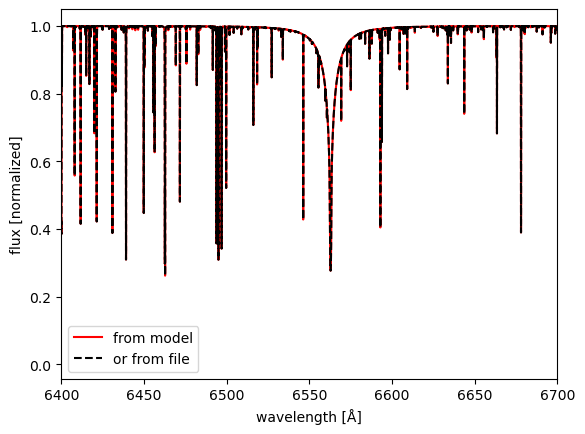

In [44]:
f, ax = plt.subplots(1, 1)

ax.plot(s.λ, s.spectrum, lw=1.5, label="from model", color="r")
ax.plot(spec_data[:, 1], spec_data[:, 2], lw=1.5, label="or from file", color="k", ls="--")

ax.set_ylabel("flux [normalized]")
ax.set_xlabel("wavelength [Å]")
ax.set_xlim(6400, 6700)
ax.legend();